In [ ]:
# Coffee Sales Analysis & Revenue Prediction using Machine Learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [ ]:
df = pd.read_csv("C:\\Users\\hari om\\Downloads\\Coffe_sales.csv")
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [5]:
#shape of dataset
df.shape

(3547, 11)

In [6]:
#column names
df.columns

Index(['hour_of_day', 'cash_type', 'money', 'coffee_name', 'Time_of_Day',
       'Weekday', 'Month_name', 'Weekdaysort', 'Monthsort', 'Date', 'Time'],
      dtype='object')

In [7]:
#data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


In [29]:
#statistical summary
df.describe()

,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


In [ ]:
# check missng value
print(df.isnull().sum())

hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

In [52]:
# Convert Date
# Extract useful features

df["Date"] = pd.to_datetime(df["Date"])

df["Day"] = df["Date"].dt.day

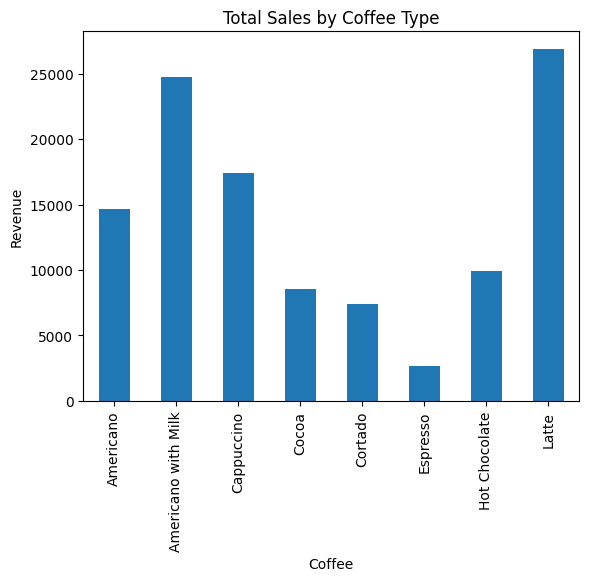

In [ ]:
#Exploratory Data Analysis (EDA)
# Sales by Coffee Type
coffee_sales = df.groupby("coffee_name")["money"].sum()

coffee_sales.plot(kind="bar")
plt.title("Total Sales by Coffee Type")
plt.xlabel("Coffee")
plt.ylabel("Revenue")
plt.show()

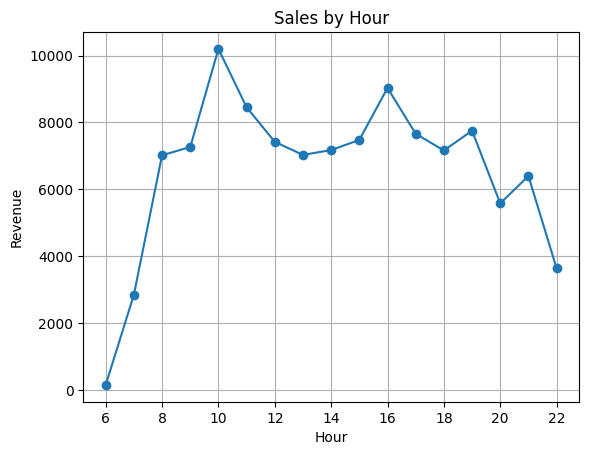

In [ ]:
# Sales by hour
hour_sales = df.groupby("hour_of_day")["money"].sum()

hour_sales.plot(kind="line", marker='o')
plt.title("Sales by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.grid()
plt.show()

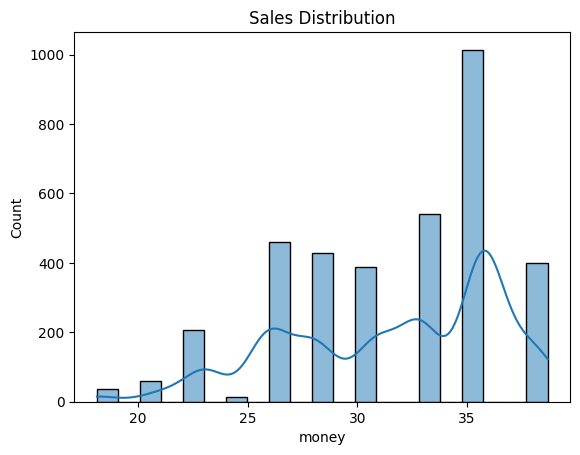

In [ ]:
#Distribution
sns.histplot(df["money"], kde=True)
plt.title("Sales Distribution")
plt.show()

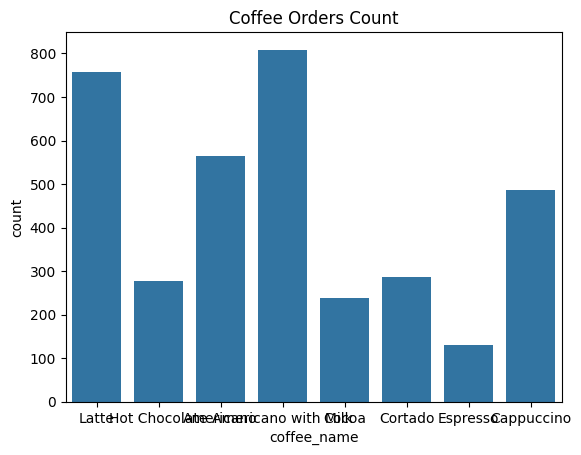

In [ ]:
#Coffee Orders Count
sns.countplot(x="coffee_name", data=df)
plt.title("Coffee Orders Count")
plt.show()

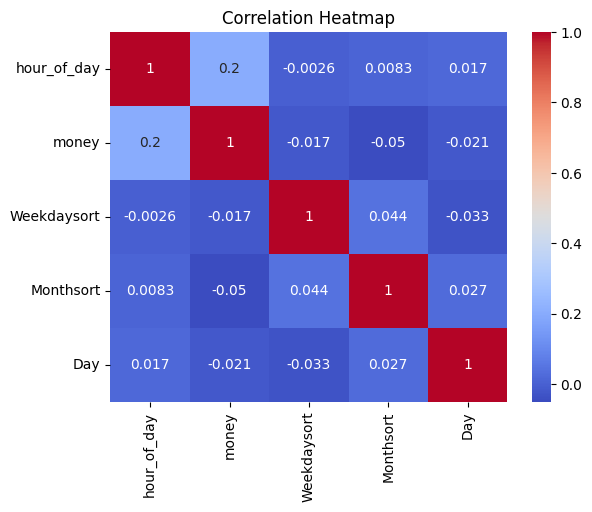

In [ ]:
# Correlation Heatmap
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [58]:
print("Insights:")
print("- Latte and Americano with Milk generate highest revenue")
print("- Peak sales occur between 10 AM to 12 PM")
print("- Sales are consistent across weekdays")

Insights:
- Latte and Americano with Milk generate highest revenue
- Peak sales occur between 10 AM to 12 PM
- Sales are consistent across weekdays


In [59]:
#Feature Engineering and Encoding
df_encoded = pd.get_dummies(df, columns=["coffee_name", "cash_type", "Time_of_Day"], drop_first=True)

# Drop unnecessary columns
df_encoded = df_encoded.drop(["Date", "Time", "Month_name", "Weekday"], axis=1)

In [60]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("money", axis=1)
y = df_encoded["money"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = preds

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # evaluation

for name, preds in results.items():
    print(f"\n{name}")
    print("MSE:", mean_squared_error(y_test, preds))
    print("MAE:", mean_absolute_error(y_test, preds))
    print("R2:", r2_score(y_test, preds))


Linear Regression
MSE: 2.9402007476126504
MAE: 1.4954808290227868
R2: 0.8714761501248693

Decision Tree
MSE: 0.4382670422535215
MAE: 0.1352676056338332
R2: 0.9808422035163601

Random Forest
MSE: 0.2884272859290107
MAE: 0.17180681690145413
R2: 0.9873920904119452


In [65]:
best_model = RandomForestRegressor()
best_model.fit(X_train, y_train)

final_preds = best_model.predict(X_test)

In [66]:
print("Best Model: Random Forest")
print("R2 Score:", r2_score(y_test, final_preds))

Best Model: Random Forest
R2 Score: 0.9882866556922214
